# Aufgabe 1

Plotten der Position zur Zeit

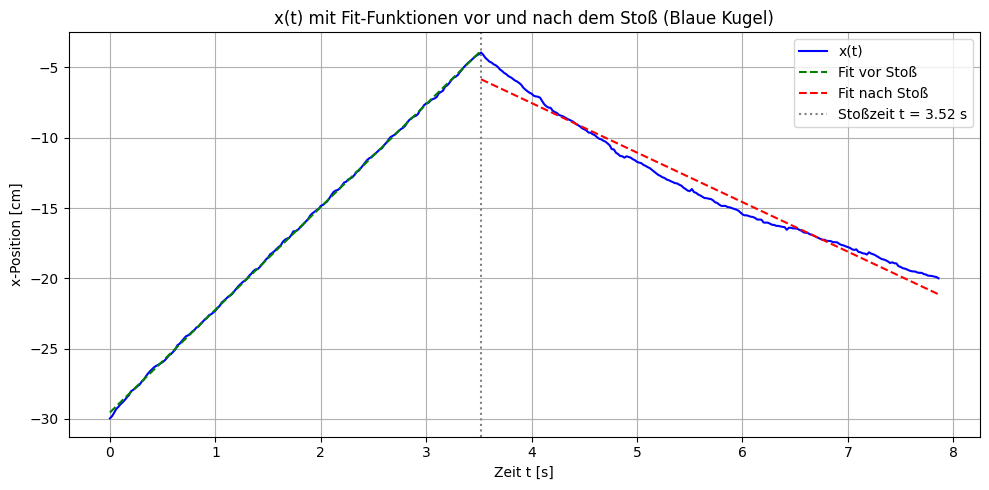

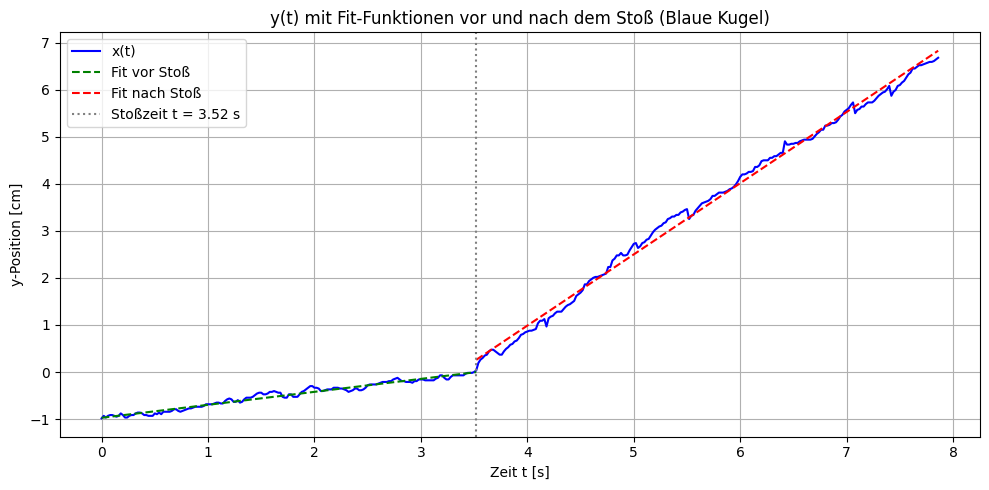

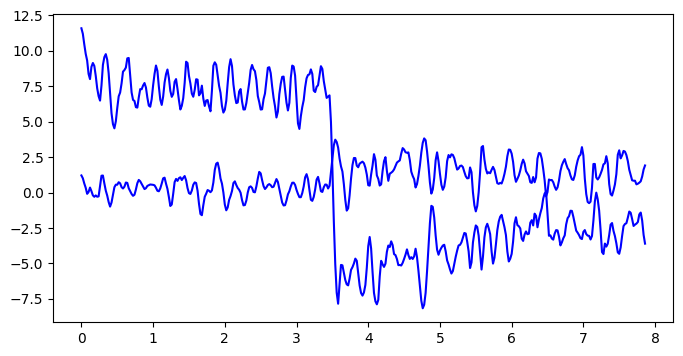

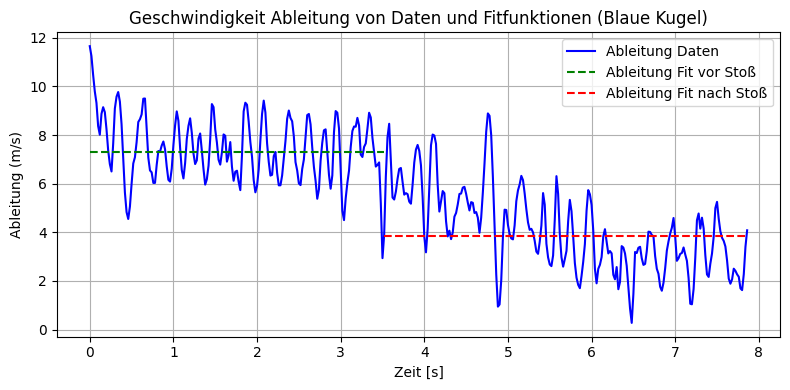

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# a. CSV einlesen & Positionen vs. Zeit plotten
df = pd.read_csv('Data_Blaue_Kugel.csv', usecols=[0,1,2])  # nur t, x, y
df.columns = ['t', 'x', 'y']

# Zeitpunkte definieren
stoßzeit = 3.52

# Daten aufteilen
df_vor = df[df['t'] <= stoßzeit]
df_nach = df[df['t'] >= stoßzeit]

# Lineare Fits durchführen
fit_vor_x = np.polyfit(df_vor['t'], df_vor['x'], 1)   # Grad 1 = lineare Regression
fit_nach_x = np.polyfit(df_nach['t'], df_nach['x'], 1)
fit_vor_y = np.polyfit(df_vor['t'], df_vor['y'], 1)   # Grad 1 = lineare Regression
fit_nach_y = np.polyfit(df_nach['t'], df_nach['y'], 1)

# Fit-Funktionen erstellen
t_fit_vor = np.linspace(df_vor['t'].min(), df_vor['t'].max(), 100)
x_fit_vor = np.polyval(fit_vor_x, t_fit_vor)
t_fit_nach = np.linspace(df_nach['t'].min(), df_nach['t'].max(), 100)
x_fit_nach = np.polyval(fit_nach_x, t_fit_nach)
y_fit_vor = np.polyval(fit_vor_y, t_fit_vor)
y_fit_nach = np.polyval(fit_nach_y, t_fit_nach)


# Plot
plt.figure(figsize=(10, 5))
plt.plot(df['t'], df['x'], label='x(t)', color='blue')
plt.plot(t_fit_vor, x_fit_vor, label='Fit vor Stoß', color='green', linestyle='--')
plt.plot(t_fit_nach, x_fit_nach, label='Fit nach Stoß', color='red', linestyle='--')
plt.axvline(x=stoßzeit, color='gray', linestyle=':', label='Stoßzeit t = 3.52 s')
plt.xlabel('Zeit t [s]')
plt.ylabel('x-Position [cm]')
plt.title('x(t) mit Fit-Funktionen vor und nach dem Stoß (Blaue Kugel)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(df['t'], df['y'], label='x(t)', color='blue')
plt.plot(t_fit_vor, y_fit_vor, label='Fit vor Stoß', color='green', linestyle='--')
plt.plot(t_fit_nach, y_fit_nach, label='Fit nach Stoß', color='red', linestyle='--')
plt.axvline(x=stoßzeit, color='gray', linestyle=':', label='Stoßzeit t = 3.52 s')
plt.xlabel('Zeit t [s]')
plt.ylabel('y-Position [cm]')
plt.title('y(t) mit Fit-Funktionen vor und nach dem Stoß (Blaue Kugel)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# b. Geschwindigkeiten vor und nach dem Stoß (lineare Regression in zwei Bereichen)

# Ableitung von x und y
x_smooth = savgol_filter(df['x'], window_length=9, polyorder=3)
y_smooth = savgol_filter(df['y'], window_length=9, polyorder=3)
v_x = np.gradient(x_smooth, df['t'])
v_y = np.gradient(y_smooth, df['t'])
v = np.sqrt(v_x**2 + v_y**2)

#Ableitung vom Fit für x und y
v_fit_vor_x = np.polyval(np.polyder(fit_vor_x), t_fit_vor)
v_fit_nach_x = np.polyval(np.polyder(fit_nach_x), t_fit_nach)
v_fit_vor_y = np.polyval(np.polyder(fit_vor_y), t_fit_vor)
v_fit_nach_y = np.polyval(np.polyder(fit_nach_y), t_fit_nach)

v_vor = np.sqrt(v_fit_vor_x**2 + v_fit_vor_y**2)
v_nach = np.sqrt(v_fit_nach_x**2 + v_fit_nach_y**2)



# Plot
plt.figure(figsize=(8, 4))
plt.plot(df['t'], v_x, label="dx/dt", color="blue")
plt.plot(df['t'], v_y, label="dx/dt", color="blue")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(df['t'], v, label="Ableitung Daten", color="blue")
plt.plot(t_fit_vor, v_vor, label='Ableitung Fit vor Stoß', color='green', linestyle='--')
plt.plot(t_fit_nach, v_nach, label='Ableitung Fit nach Stoß', color='red', linestyle='--')
plt.xlabel("Zeit [s]")
plt.ylabel("Ableitung (m/s)")
plt.title("Geschwindigkeit Ableitung von Daten und Fitfunktionen (Blaue Kugel)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

